In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_confint

In [2]:
df = pd.read_csv("marketing_AB.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [4]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']


In [7]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [8]:
conversion_rate = df.groupby("test group")["converted"].mean() * 100

print(conversion_rate)

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


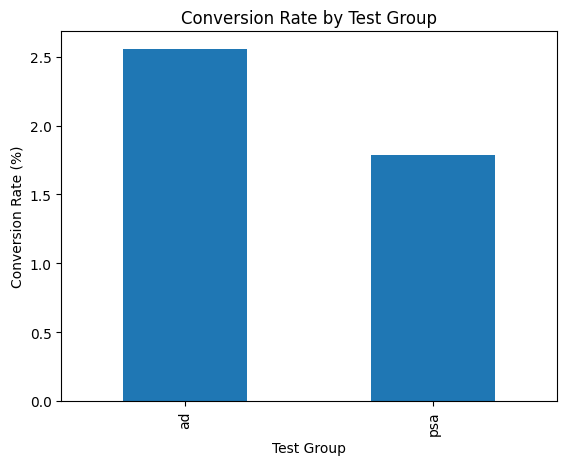

In [9]:
import matplotlib.pyplot as plt

conversion_rate.plot(kind="bar")

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [10]:
contingency_table = pd.crosstab(df["test group"], df["converted"])

print(contingency_table)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420


In [11]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)

Chi-Square Statistic: 54.005823883685245
P-value: 1.9989623063390075e-13


In [13]:
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions (True values)
success = contingency_table[True]

# Total users in each group
total = contingency_table.sum(axis=1)

# Perform Z-test
z_stat, p_value = proportions_ztest(success.values, total.values)

print("Z Statistic:", z_stat)
print("P-value:", p_value)

Z Statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [14]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("The difference between the two groups is statistically significant.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference between the two groups.")

Reject the Null Hypothesis
The difference between the two groups is statistically significant.


In [15]:
from statsmodels.stats.proportion import proportion_confint

# Number of conversions
success = contingency_table[True]

# Total users
total = contingency_table.sum(axis=1)

# Confidence Interval for each group
for group in contingency_table.index:
    low, high = proportion_confint(
        count=success[group],
        nobs=total[group],
        alpha=0.05,
        method='normal'
    )

    print(f"\n{group}")
    print(f"95% Confidence Interval: ({low:.4f}, {high:.4f})")


ad
95% Confidence Interval: (0.0251, 0.0260)

psa
95% Confidence Interval: (0.0162, 0.0195)


In [16]:
import numpy as np

# Conversion rates
p1 = success["ad"] / total["ad"]
p2 = success["psa"] / total["psa"]

# Cohen's h
effect_size = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

print("Effect Size (Cohen's h):", effect_size)

Effect Size (Cohen's h): 0.053002578606030915


In [17]:
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()

power = analysis.power(
    effect_size=abs(effect_size),
    nobs1=total["ad"],
    ratio=total["psa"] / total["ad"],
    alpha=0.05
)

print("Statistical Power:", power)

Statistical Power: 0.9999999990438161


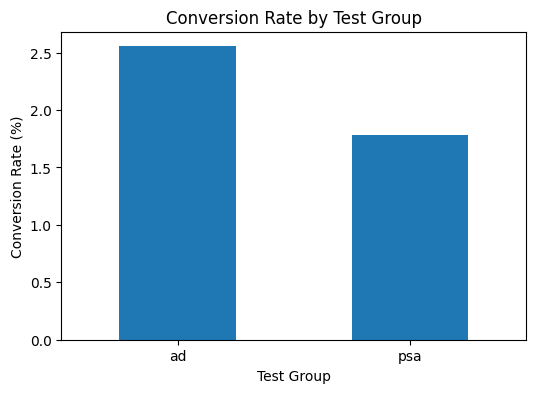

In [18]:
conversion_rate = df.groupby("test group")["converted"].mean() * 100

plt.figure(figsize=(6,4))

conversion_rate.plot(kind="bar")

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)

plt.show()

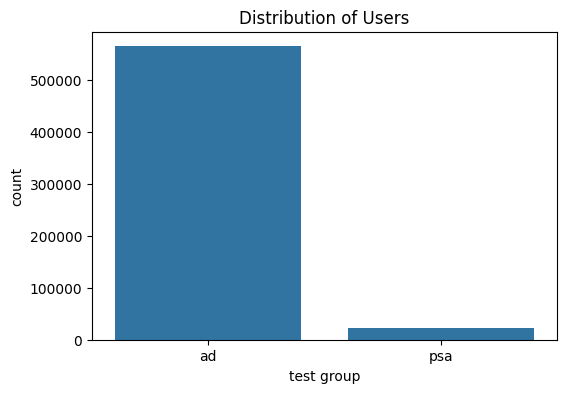

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="test group")

plt.title("Distribution of Users")

plt.show()